🔷 Part B – Practical Testing Task 

In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistics
from scipy import stats
import statsmodels.api as sm

In [2]:
# Load CSV file
df = pd.read_csv("spread_locator_dataset - spread_locator_dataset.csv.csv")

# Show data
print(df.head())

# Check info
print(df.info())

                         transaction_id customer_id  transaction_amount  \
0  e98aa092-3770-4fdb-9502-5b5a6a244811    CUST2824             3821.34   
1  11ba6918-dba0-41e5-96cf-f5a7b95f0103    CUST1409             2781.84   
2  82b7654b-6eb7-4579-89a0-1a9edec0a7bb    CUST5506             4120.97   
3  f7166574-f400-4d53-b526-0b11f6619ddf    CUST5012             6383.78   
4  8632fe26-b507-4068-9c68-1b2fa04fecb3    CUST4657             2651.61   

  transaction_date  transaction_count region transaction_status  
0        1/26/2023                  3  North               Fail  
1        1/28/2023                  0   East               Fail  
2        1/28/2023                  0  South               Fail  
3        1/18/2023                  2  South            Success  
4         1/4/2023                  4  North            Success  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220 entries, 0 to 219
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  


In [13]:
# Convert date column
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# Convert success/fail into 1/0 (Bernoulli)
df['success'] = df['transaction_status'].map({'Success':1, 'Fail':0})

# Drop missing values
df = df.dropna()

In [14]:
# Probability of success

p = df['success'].mean()
print("Bernoulli Probability:", p)

Bernoulli Probability: 0.44545454545454544


In [15]:
# Weekly transactions
weekly = df.groupby('customer_id')['transaction_count'].sum()

# Mean & variance
print("Mean:", weekly.mean())
print("Variance:", weekly.var())

Mean: 2.8940092165898617
Variance: 3.354454685099845


Lambda: 7.096774193548387


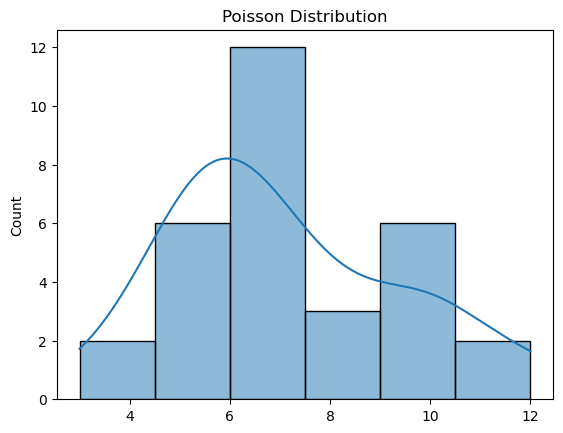

In [7]:
# Daily transactions count
daily = df.groupby('transaction_date').size()

# Lambda (mean)

lam = daily.mean()
print("Lambda:", lam)
  
# Plot

sns.histplot(daily, kde=True)
plt.title("Poisson Distribution")
plt.show()

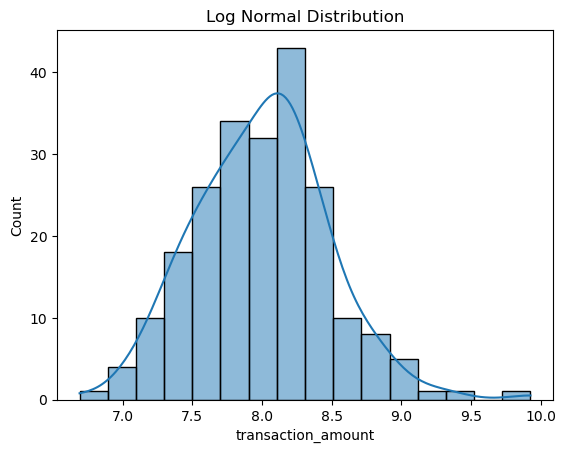

In [8]:
# Transaction amount

amount = df['transaction_amount']

# Log transform

log_amount = np.log(amount)

sns.histplot(log_amount, kde=True)
plt.title("Log Normal Distribution")
plt.show()

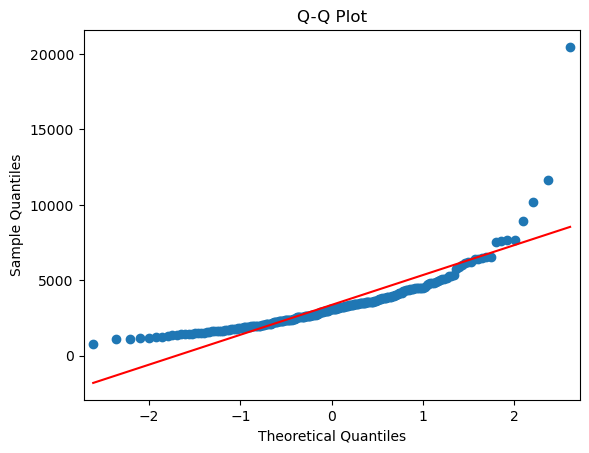

In [9]:
# Q-Q plot

sm.qqplot(amount, line='s')
plt.title("Q-Q Plot")
plt.show()

Lambda: -0.18083391951050778


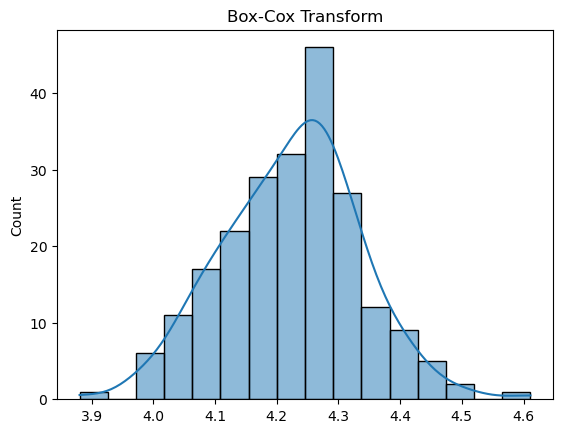

In [10]:
# Box-Cox (only positive values)

boxcox_data, lam = stats.boxcox(amount)

print("Lambda:", lam)

sns.histplot(boxcox_data, kde=True)
plt.title("Box-Cox Transform")
plt.show()

In [11]:
# Z-score

z_scores = stats.zscore(amount)


# Probability > 5000

prob = np.mean(amount > 5000)

print("Probability > 5000:", prob)

Probability > 5000: 0.11363636363636363


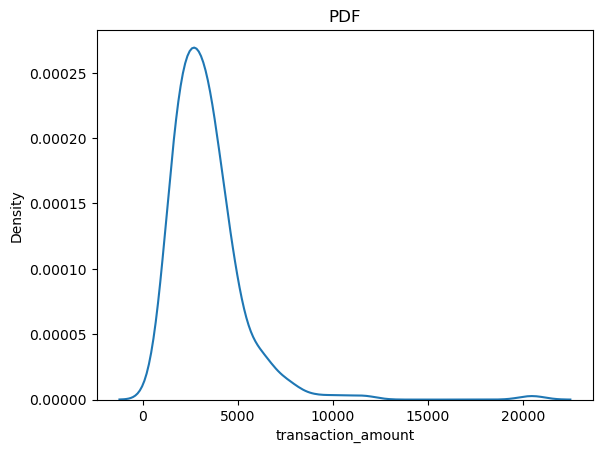

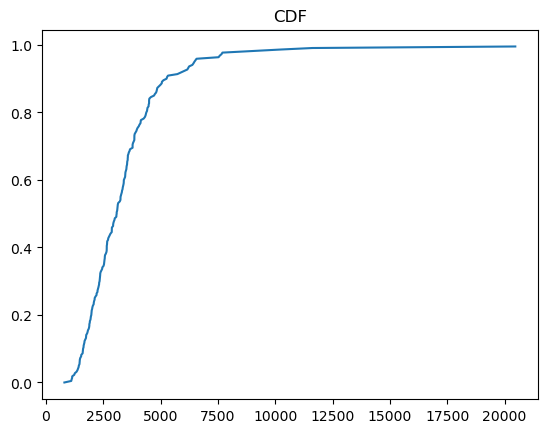

In [12]:
# PDF

sns.kdeplot(amount)
plt.title("PDF")
plt.show()

# CDF
sorted_data = np.sort(amount)
cdf = np.arange(len(amount)) / float(len(amount))

plt.plot(sorted_data, cdf)
plt.title("CDF")
plt.show()